In [73]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [78]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)
N = X*Y

t = 1
mu = 0 * t * np.ones(lattice.X)

h0 = -6 * t
h = np.ones_like(mu) * h0

H = Hamiltonian(t, mu, lattice, hz=h)

In [79]:
energies = np.linspace(-10, 10, 2000) 
dos_up, dos_dn = H.dos_spin_resolved(energies, eta=0.1)

In [80]:
H = Hamiltonian(t, mu, lattice)
energies = np.linspace(-10, 10, 2000) 
dos_up1, dos_dn1 = H.dos_spin_resolved(energies, eta=0.1)

H = Hamiltonian(t, mu, lattice, hz=h/3)
energies = np.linspace(-10, 10, 2000) 
dos_up2, dos_dn2 = H.dos_spin_resolved(energies, eta=0.1)

H = Hamiltonian(t, mu, lattice, hz=h)
energies = np.linspace(-10, 10, 2000) 
dos_up3, dos_dn3 = H.dos_spin_resolved(energies, eta=0.1)

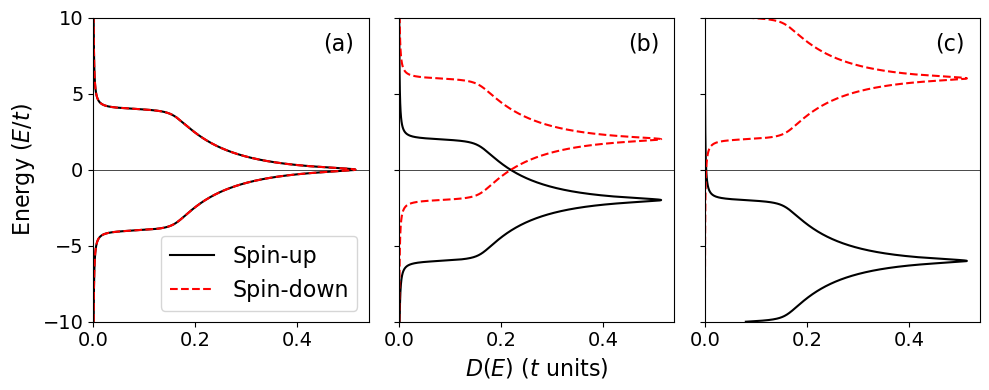

In [84]:
fig, axs = plt.subplots(1, 3, figsize=(10,4), sharey=True)

axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].plot(dos_up1/N, energies, color='black', label='Spin-up')
axs[0].plot(dos_dn1/N, energies, '--', color='red', label='Spin-down')
axs[0].set_xlim(0, None)
axs[0].set_ylim(-10, 10)
axs[0].set_ylabel(r'Energy ($E/t$)', fontsize=16)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].legend(fontsize=16, loc='lower right')
axs[0].text(0.48, 7.8, r'(a)', fontsize=16, ha='center')

axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].plot(dos_up2/N, energies, color='black')
axs[1].plot(dos_dn2/N, energies, '--', color='red')
# axs[1].set_yticks([])
axs[1].set_xlim(0, None)
axs[1].set_ylim(-10, 10)
axs[1].tick_params(axis='x', labelsize=14)
axs[1].tick_params(axis='y', labelsize=14)
axs[1].set_xlabel(r'$D(E)$ ($t$ units)', fontsize=16)
axs[1].text(0.48, 7.8, r'(b)', fontsize=16, ha='center')

axs[2].axhline(0, color='black', linewidth=0.5)
axs[2].plot(dos_up3/N, energies, color='black')
axs[2].plot(dos_dn3/N, energies, '--', color='red')
# axs[2].set_yticks([])
axs[2].set_xlim(0, None)
axs[2].set_ylim(-10, 10)
axs[2].tick_params(axis='x', labelsize=14)
axs[2].tick_params(axis='y', labelsize=14)
axs[2].text(0.48, 7.8, r'(c)', fontsize=16, ha='center')

plt.tight_layout()
plt.savefig('../figures/ferromagnet_dos.svg', bbox_inches='tight')
plt.show()